### $\S \ 2.$  Limit of a Function 

#### 1. Definitions and examples 

Let $E$ be a subset of the set of real number $\R$, and let $a$ be a limit point of the set $E$. Let $f : E \to \R$ be a real-valued function defined on $E$. 

We wish to state precisely what it means for the values $f(x)$ of the function $f$ to approach some number $A$ as the point $x \in E$ appoaches $a$, which it is natual to call the limit of the values of the function $f$ or the limit of the function $f$ as $x$ tends to $a$. 

**Definition 1.** We say that a function $f : E \to \R$ tends to $A$ as $x$ to $a$, or that $A$ is the limit of the function $f$ as $x$ tends to $a$, if for every number $\varepsilon > 0$ there exists a number $\delta > 0$ such that for every point $x \in E$ for which $0 < |x - a| < \delta$, the inequality $|f(x) - A| < \varepsilon$ holds. 

In logical symbolism, the formulated conditions are written as:
$$\forall \varepsilon > 0 \ \exists > 0 \ \forall x \in E (0 < |x - a| < \delta \Rightarrow  |f(x) - A| < \varepsilon)$$

if $A$ is the limit of the function $f(x)$ as x tends to the point $a$ along the set $E$, we write $f(x) \to A$ as $x \to a$, $x \in E$, or $\lim_{x \to a, x \in E} f(x) = A$. Instead of the symbol $x \to a, x \in E$, we shall, as a rule, use the shorter notation $E \ni x \to a$ and istead of $\lim_{x \to a, x \in E} f(x)$ we will write $\lim_{E \ni x \to a} f(x) = A$



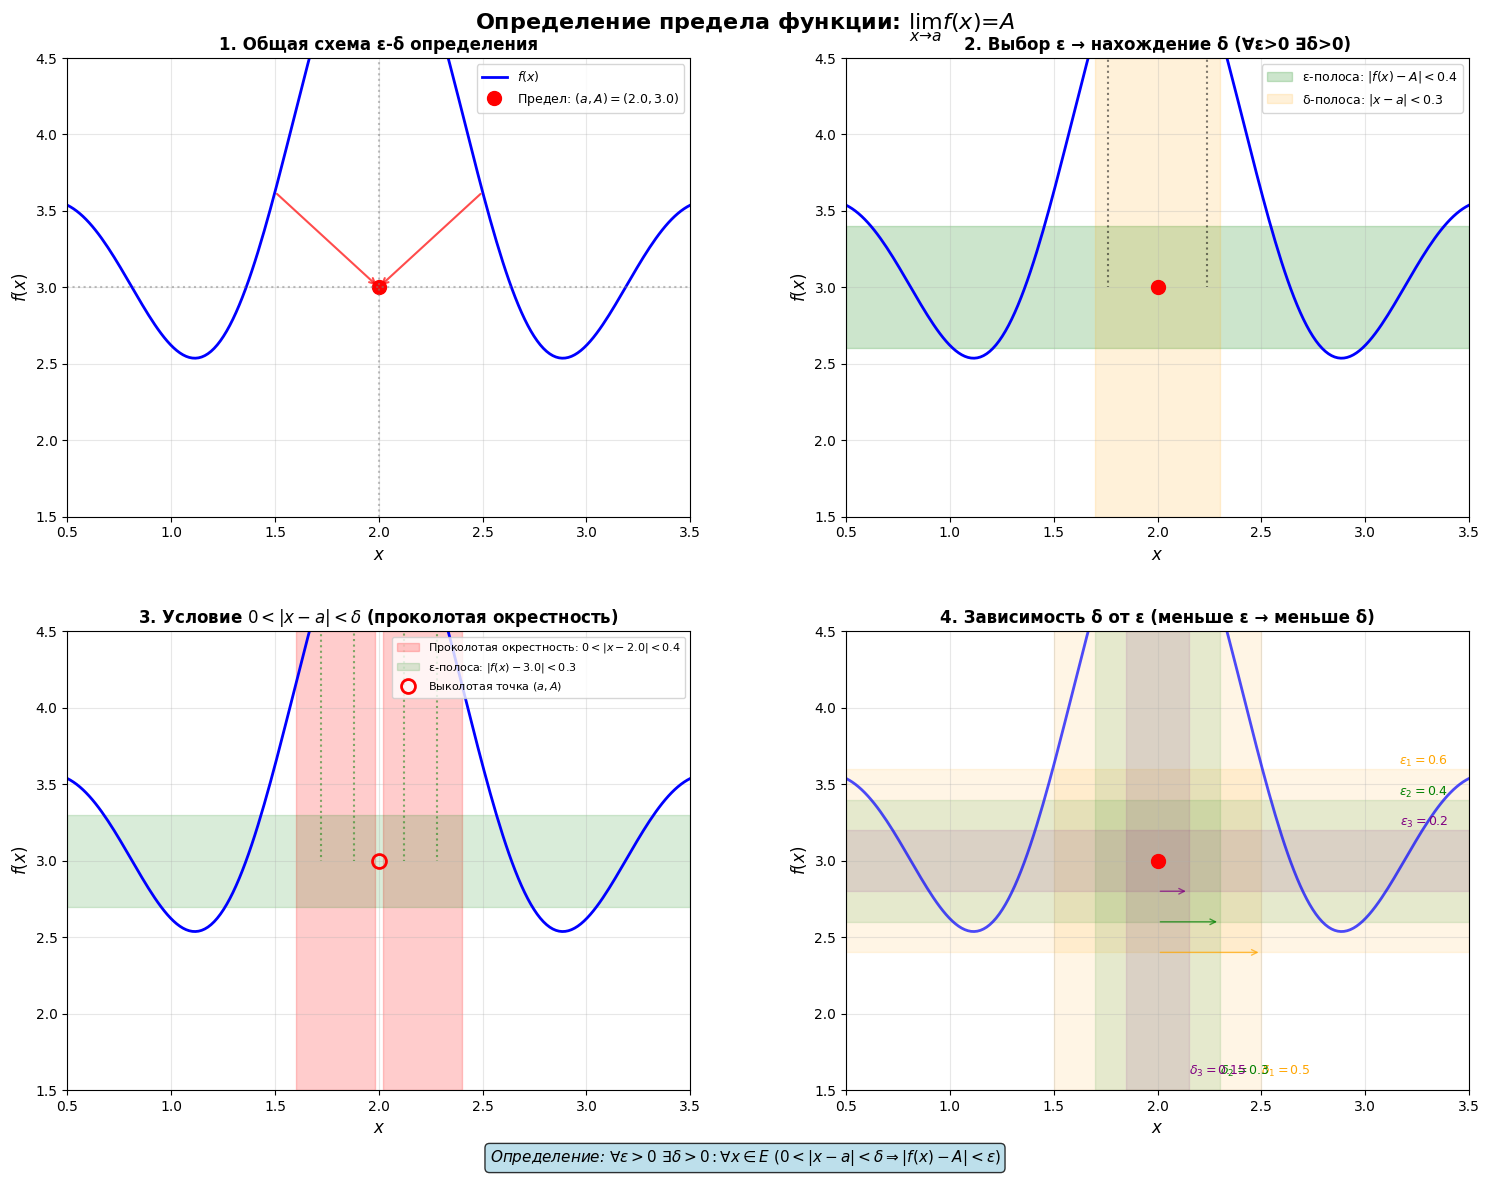

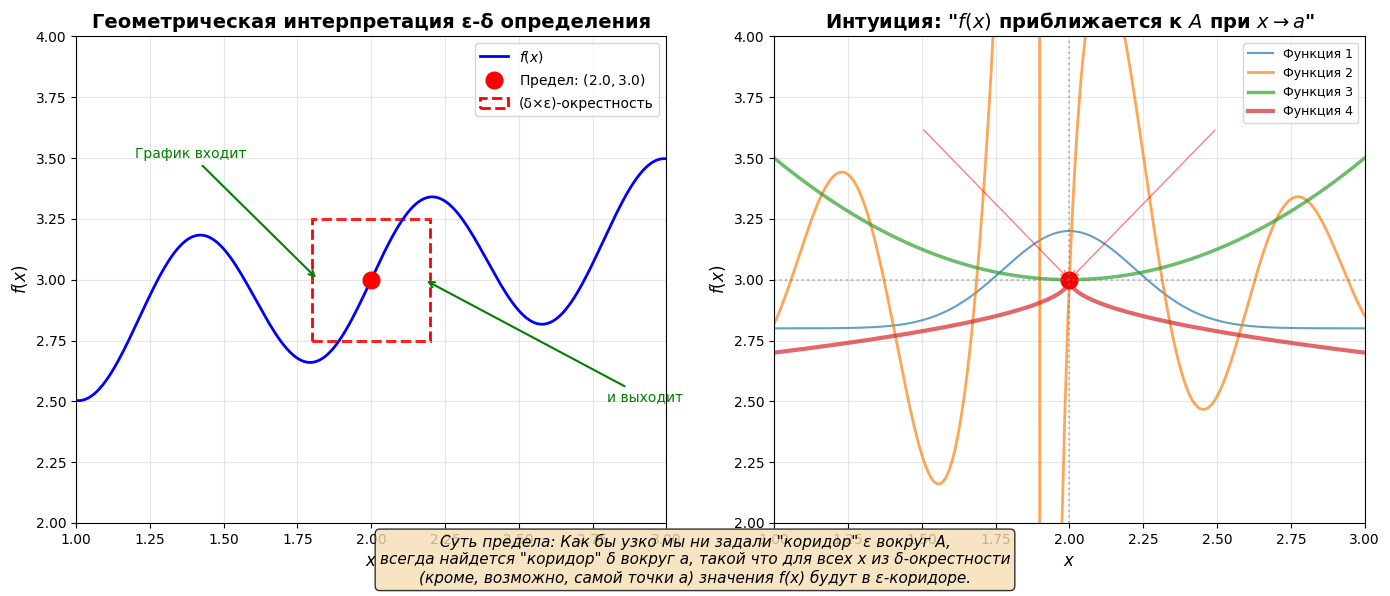

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
import matplotlib.patches as patches

# Создаем фигуру
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Определение предела функции: $\\lim_{x \\to a} f(x) = A$', 
             fontsize=16, fontweight='bold', y=0.98)

# Параметры функции
a = 2.0  # Точка, к которой стремится x
A = 3.0  # Предел функции
x_range = np.linspace(0.5, 3.5, 400)

# Функция с разрывом/особенностью в точке a (но с пределом)
def f(x):
    return A + 0.5*np.sin(5*(x-a))/(x-a) + 0.1*(x-a)**2

# Уберем точку a из области определения для наглядности
x_points = np.concatenate([
    np.linspace(0.5, a-0.01, 100),
    np.linspace(a+0.01, 3.5, 100)
])
y_points = f(x_points)

# График 1: Общая схема определения
ax1 = axes[0, 0]
ax1.set_title('1. Общая схема ε-δ определения', fontsize=12, fontweight='bold')

# Рисуем функцию
ax1.plot(x_points, y_points, 'b-', linewidth=2, label='$f(x)$')
ax1.plot(a, A, 'ro', markersize=10, label=f'Предел: $(a, A)=({a},{A})$')

# Показываем стрелку стремления
ax1.annotate('', xy=(a, A), xytext=(a-0.5, f(a-0.5)),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5, alpha=0.7))
ax1.annotate('', xy=(a, A), xytext=(a+0.5, f(a+0.5)),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5, alpha=0.7))

# Рисуем оси стремления
ax1.axvline(x=a, color='gray', linestyle=':', alpha=0.5)
ax1.axhline(y=A, color='gray', linestyle=':', alpha=0.5)

ax1.set_xlabel('$x$', fontsize=12)
ax1.set_ylabel('$f(x)$', fontsize=12)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 3.5)
ax1.set_ylim(1.5, 4.5)

# График 2: Выбор ε и соответствующего δ
ax2 = axes[0, 1]
ax2.set_title('2. Выбор ε → нахождение δ (∀ε>0 ∃δ>0)', fontsize=12, fontweight='bold')

# Рисуем функцию
ax2.plot(x_points, y_points, 'b-', linewidth=2)

# Задаем ε и находим соответствующее δ
epsilon = 0.4
# Для простоты: находим δ такое, что если |x-a| < δ, то |f(x)-A| < ε
# В реальности это требует анализа функции
delta = 0.3

# Рисуем ε-полосу вокруг A
ax2.axhspan(A - epsilon, A + epsilon, alpha=0.2, color='green',
           label=f'ε-полоса: $|f(x)-A| < {epsilon}$')

# Рисуем δ-полосу вокруг a
ax2.axvspan(a - delta, a + delta, alpha=0.15, color='orange',
           label=f'δ-полоса: $|x-a| < {delta}$')

# Показываем связь: из δ-полосы в ε-полосу
for x_test in [a-delta*0.8, a, a+delta*0.8]:
    if x_test != a:
        ax2.plot([x_test, x_test], [f(x_test), A], 'k:', alpha=0.5)
        ax2.plot([x_test, a], [f(x_test), f(x_test)], 'k:', alpha=0.5)

ax2.plot(a, A, 'ro', markersize=10)
ax2.set_xlabel('$x$', fontsize=12)
ax2.set_ylabel('$f(x)$', fontsize=12)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.5, 3.5)
ax2.set_ylim(1.5, 4.5)

# График 3: Логическая структура определения (0 < |x-a| < δ)
ax3 = axes[1, 0]
ax3.set_title('3. Условие $0 < |x-a| < δ$ (проколотая окрестность)', 
              fontsize=12, fontweight='bold')

# Рисуем функцию
ax3.plot(x_points, y_points, 'b-', linewidth=2)

# Проколотая δ-окрестность (без точки a)
delta_proc = 0.4
# Левая часть
ax3.axvspan(a - delta_proc, a - 0.02, alpha=0.2, color='red',
           label=f'Проколотая окрестность: $0 < |x-{a}| < {delta_proc}$')
# Правая часть
ax3.axvspan(a + 0.02, a + delta_proc, alpha=0.2, color='red')

# ε-полоса
epsilon_proc = 0.3
ax3.axhspan(A - epsilon_proc, A + epsilon_proc, alpha=0.15, color='green',
           label=f'ε-полоса: $|f(x)-{A}| < {epsilon_proc}$')

# Отмечаем выколотую точку a
ax3.plot(a, A, 'ro', markersize=10, markerfacecolor='none', markeredgewidth=2,
        label='Выколотая точка $(a, A)$')

# Показываем несколько точек из проколотой окрестности
x_test_points = [a - delta_proc*0.7, a - delta_proc*0.3, 
                 a + delta_proc*0.3, a + delta_proc*0.7]
for xp in x_test_points:
    yp = f(xp)
    ax3.plot(xp, yp, 'go', markersize=8)
    ax3.plot([xp, xp], [yp, A], 'g:', alpha=0.5)

ax3.set_xlabel('$x$', fontsize=12)
ax3.set_ylabel('$f(x)$', fontsize=12)
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0.5, 3.5)
ax3.set_ylim(1.5, 4.5)

# График 4: Разные ε требуют разных δ
ax4 = axes[1, 1]
ax4.set_title('4. Зависимость δ от ε (меньше ε → меньше δ)', 
              fontsize=12, fontweight='bold')

# Рисуем функцию
ax4.plot(x_points, y_points, 'b-', linewidth=2, alpha=0.7)
ax4.plot(a, A, 'ro', markersize=10)

# Показываем несколько пар (ε, δ)
epsilons = [0.6, 0.4, 0.2]
deltas = [0.5, 0.3, 0.15]  # Обычно δ уменьшается с ε
colors = ['orange', 'green', 'purple']

for i, (eps, delt, col) in enumerate(zip(epsilons, deltas, colors)):
    # ε-полоса
    ax4.axhspan(A - eps, A + eps, alpha=0.1, color=col)
    # δ-полоса
    ax4.axvspan(a - delt, a + delt, alpha=0.1, color=col)
    
    # Подписи
    ax4.text(3.4, A + eps, f'$ε_{i+1}={eps}$', 
            fontsize=9, color=col, va='bottom', ha='right')
    ax4.text(a + delt, 1.6, f'$δ_{i+1}={delt}$', 
            fontsize=9, color=col, ha='left')
    
    # Стрелка связи
    ax4.annotate('', xy=(a, A-eps), xytext=(a+delt, A-eps),
                arrowprops=dict(arrowstyle='<-', color=col, lw=1, alpha=0.7))

ax4.set_xlabel('$x$', fontsize=12)
ax4.set_ylabel('$f(x)$', fontsize=12)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 3.5)
ax4.set_ylim(1.5, 4.5)

# Добавляем пояснительную схему в центре
fig.text(0.5, 0.02, 
         r'Определение: $\forall \varepsilon > 0\ \exists \delta > 0: \forall x \in E\ (0 < |x-a| < \delta \Rightarrow |f(x)-A| < \varepsilon)$',
         ha='center', fontsize=11, style='italic',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(bottom=0.08, top=0.94, hspace=0.25, wspace=0.25)
plt.show()

# Дополнительная визуализация: геометрический смысл
fig2, (ax5, ax6) = plt.subplots(1, 2, figsize=(14, 6))

# Левый график: Процесс проверки определения
ax5.set_title('Геометрическая интерпретация ε-δ определения', fontsize=14, fontweight='bold')

# Функция с явным пределом
x_det = np.linspace(1.0, 3.0, 200)
x_det_no_a = np.concatenate([x_det[x_det < a], x_det[x_det > a]])
y_det = A + 0.3*np.sin(8*(x_det_no_a - a)) + 0.2*(x_det_no_a - a)

ax5.plot(x_det_no_a, y_det, 'b-', linewidth=2, label='$f(x)$')
ax5.plot(a, A, 'ro', markersize=12, label=f'Предел: $({a},{A})$')

# Показываем "игру" ε-δ
epsilon_ex = 0.25
delta_ex = 0.2

# Рисуем прямоугольник (δ × ε)
rect = patches.Rectangle((a-delta_ex, A-epsilon_ex), 2*delta_ex, 2*epsilon_ex,
                         linewidth=2, edgecolor='red', facecolor='none', 
                         linestyle='--', label='(δ×ε)-окрестность')
ax5.add_patch(rect)

# Показываем, что график входит в прямоугольник с боков
ax5.annotate('График входит', xy=(a-delta_ex*0.9, A), 
            xytext=(1.2, A+0.5),
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
            fontsize=10, color='green')
ax5.annotate('и выходит', xy=(a+delta_ex*0.9, A), 
            xytext=(2.8, A-0.5),
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
            fontsize=10, color='green')

ax5.set_xlabel('$x$', fontsize=12)
ax5.set_ylabel('$f(x)$', fontsize=12)
ax5.legend(loc='upper right', fontsize=10)
ax5.grid(True, alpha=0.3)
ax5.set_xlim(1.0, 3.0)
ax5.set_ylim(2.0, 4.0)

# Правый график: Что означает "стремится"
ax6.set_title('Интуиция: "$f(x)$ приближается к $A$ при $x \\to a$"', 
              fontsize=14, fontweight='bold')

# Несколько функций, стремящихся к одному пределу
for i in range(4):
    # Разные функции с одним пределом
    if i == 0:
        y_fun = A + 0.4*np.exp(-10*(x_det - a)**2) - 0.2
    elif i == 1:
        y_fun = A + 0.3*np.sin(10*(x_det - a))/(x_det - a + 0.1)
    elif i == 2:
        y_fun = A + 0.5*(x_det - a)**2
    else:
        y_fun = A - 0.3*np.abs(x_det - a)**0.5
    
    ax6.plot(x_det, y_fun, alpha=0.7, linewidth=1.5 + i*0.5,
            label=f'Функция {i+1}')

ax6.plot(a, A, 'ro', markersize=12)
ax6.axvline(x=a, color='gray', linestyle=':', alpha=0.5)
ax6.axhline(y=A, color='gray', linestyle=':', alpha=0.5)

# Стрелки стремления
for x_dir in [1.5, 2.5]:
    ax6.annotate('', xy=(a, A), xytext=(x_dir, f(x_dir)),
                arrowprops=dict(arrowstyle='->', color='red', 
                               lw=1, alpha=0.5))

ax6.set_xlabel('$x$', fontsize=12)
ax6.set_ylabel('$f(x)$', fontsize=12)
ax6.legend(loc='upper right', fontsize=9)
ax6.grid(True, alpha=0.3)
ax6.set_xlim(1.0, 3.0)
ax6.set_ylim(2.0, 4.0)

# Общее пояснение
fig2.text(0.5, 0.02,
         'Суть предела: Как бы узко мы ни задали "коридор" ε вокруг A,\n'
         'всегда найдется "коридор" δ вокруг a, такой что для всех x из δ-окрестности\n'
         '(кроме, возможно, самой точки a) значения f(x) будут в ε-коридоре.',
         ha='center', fontsize=11, style='italic',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

**a — The Point Towards Which the Argument x Approaches** 
$$x \to a$$
Properties of a:

1. Limit point of the set E — It can be "approached arbitrarily closely" from within E

2. Does not necessarily belong to E — The function may be undefined at point a itself!

3. "Target" for the variable x — We study the behavior of the function as it approaches a

Examples:

- If a = 2, we study f(x) as x → 2

- a can be a finite number or ±∞ (in the extended sense)

**A - The Limit Towards Which the Function Approaches**
$$f(x) \to A  as  x \to a$$
Properties of $A$:

1. Number to which the values of $f(x)$ approximate

2. "Target value" of the function - Where it "wants to go"

3. May not equal f(a) (if f(a) even exists)

Example:

- If $lim_{x→2} f(x) = 3$, then $A = 3$

- The function may "approach" 3, even if f(2) = 5 or f(2) doesn't exist

What Are ε (epsilon) and δ (delta)?
**ε - Allowable Error Along the Y-axis**

$$|f(x) - A| < \varepsilon$$
Meaning of $\varepsilon$:

1. Accuracy of approximation of function values

2. "Width of the corridor" around the value A

3. Requirement for the function: "Values f(x) must differ from A by no more than ε"

- On the graph: Horizontal band from A-ε to A+ε

**δ — Allowable Deviation Along the X-axis**
$$0 < |x - a| < δ$$
Meaning of δ:

"Zone of influence" around point a

"Width of the corridor" around argument a

Guarantee: "If x is sufficiently close to a (within δ-neighborhood), then f(x) will be close to A"

On the graph: Vertical band from a-δ to a+δ (excluding point a itself!)

RELATIONSHIP Between ε and δ: Cause and Effect
Logic of the Definition:

text
IF:    |x - a| < δ    (x is close to a)
THEN:  |f(x) - A| < ε (f(x) is close to A)
The Key Point:
δ IS CHOSEN depending on ε!

Visual Analogy:
Imagine a target:

Bullseye = point (a, A) on the graph

ε = size of the bullseye (allowable vertical deviation)

δ = how accurately you need to aim (allowable horizontal deviation)

The smaller the bullseye (smaller ε) → the more accurate your aim must be (smaller δ).


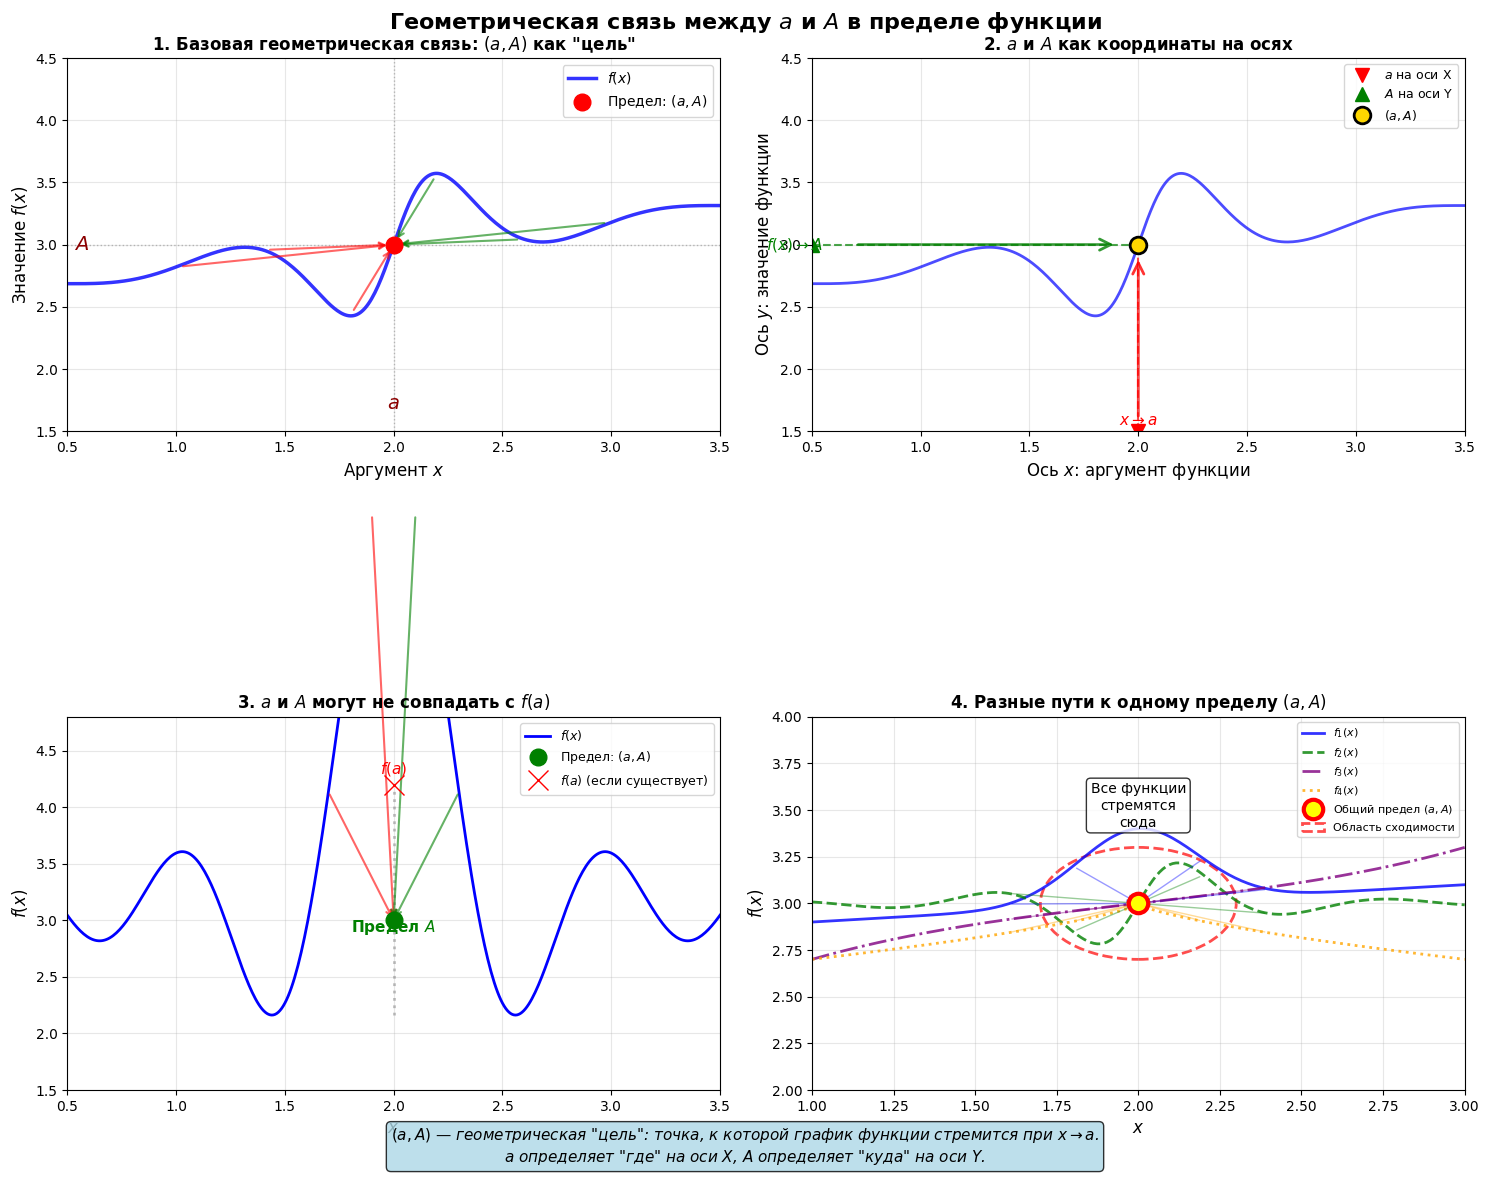

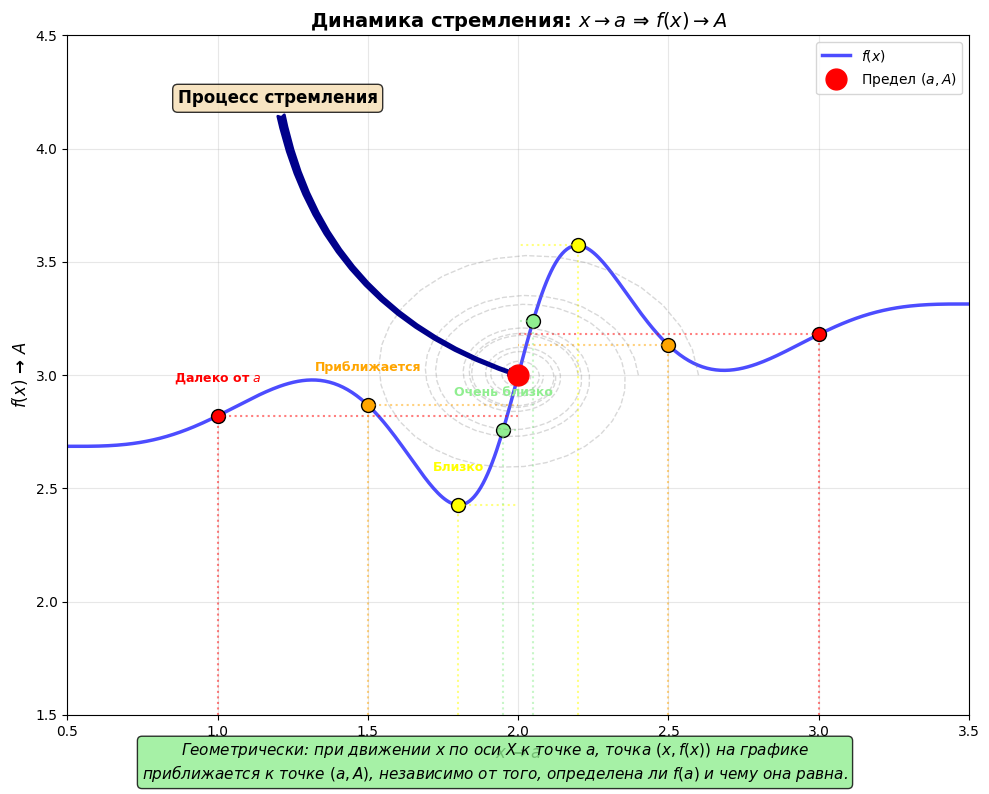

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as patches

# Создаем фигуру
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Геометрическая связь между $a$ и $A$ в пределе функции', 
             fontsize=16, fontweight='bold', y=0.98)

# Определяем параметры
a = 2.0    # Точка, к которой стремится x
A = 3.0    # Предельное значение функции

# Создаем функцию, которая стремится к пределу
x = np.linspace(0.5, 3.5, 400)
# Исключаем точку a для наглядности
x_without_a = np.concatenate([x[x < a-0.01], x[x > a+0.01]])

def f(x):
    # Функция с пределом A при x→a
    return A + 0.8 * np.sin(6*(x-a)) / (1 + 10*(x-a)**2) + 0.2*(x-a)

y = f(x_without_a)

# График 1: Основная геометрическая связь
ax1 = axes[0, 0]
ax1.set_title('1. Базовая геометрическая связь: $(a, A)$ как "цель"', 
              fontsize=12, fontweight='bold')

# Рисуем функцию
ax1.plot(x_without_a, y, 'b-', linewidth=2.5, label='$f(x)$', alpha=0.8)

# Отмечаем точку (a, A) - ПРЕДЕЛ
ax1.plot(a, A, 'ro', markersize=12, label='Предел: $(a, A)$', zorder=5)

# Показываем стрелки стремления
# Слева от a
left_points = [1.0, 1.4, 1.8]
for x_left in left_points:
    ax1.annotate('', xy=(a, A), xytext=(x_left, f(x_left)),
                arrowprops=dict(arrowstyle='->', color='red', 
                               lw=1.5, alpha=0.6, shrinkA=5, shrinkB=5))

# Справа от a
right_points = [2.2, 2.6, 3.0]
for x_right in right_points:
    ax1.annotate('', xy=(a, A), xytext=(x_right, f(x_right)),
                arrowprops=dict(arrowstyle='->', color='green', 
                               lw=1.5, alpha=0.6, shrinkA=5, shrinkB=5))

# Линии, показывающие проекции
ax1.axvline(x=a, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax1.axhline(y=A, color='gray', linestyle=':', alpha=0.5, linewidth=1)

# Подписи
ax1.text(a, 1.8, '$a$', fontsize=14, fontweight='bold', 
         ha='center', va='top', color='darkred')
ax1.text(0.6, A, '$A$', fontsize=14, fontweight='bold', 
         ha='right', va='center', color='darkred')

ax1.set_xlabel('Аргумент $x$', fontsize=12)
ax1.set_ylabel('Значение $f(x)$', fontsize=12)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 3.5)
ax1.set_ylim(1.5, 4.5)

# График 2: a как точка на оси X, A как точка на оси Y
ax2 = axes[0, 1]
ax2.set_title('2. $a$ и $A$ как координаты на осях', 
              fontsize=12, fontweight='bold')

# Рисуем функцию
ax2.plot(x_without_a, y, 'b-', linewidth=2, alpha=0.7)

# Показываем проекцию x→a на ось X
ax2.plot([a, a], [1.5, A], 'r--', linewidth=1.5, alpha=0.7)
ax2.plot(a, 1.5, 'rv', markersize=10, label='$a$ на оси X')

# Показываем проекцию f(x)→A на ось Y
ax2.plot([0.5, a], [A, A], 'g--', linewidth=1.5, alpha=0.7)
ax2.plot(0.5, A, 'g^', markersize=10, label='$A$ на оси Y')

# Точка предела
ax2.plot(a, A, 'ko', markersize=12, markerfacecolor='gold', 
        markeredgewidth=2, label='$(a, A)$')

# Анимационные стрелки
# От оси X к точке
arrow_x = FancyArrowPatch((a, 1.6), (a, A-0.1),
                         arrowstyle='->', mutation_scale=20,
                         color='red', linewidth=2, alpha=0.8)
ax2.add_patch(arrow_x)

# От оси Y к точке
arrow_y = FancyArrowPatch((0.7, A), (a-0.1, A),
                         arrowstyle='->', mutation_scale=20,
                         color='green', linewidth=2, alpha=0.8)
ax2.add_patch(arrow_y)

ax2.text(a, 1.55, '$x \\to a$', fontsize=11, fontweight='bold',
         ha='center', color='red')
ax2.text(0.55, A, '$f(x) \\to A$', fontsize=11, fontweight='bold',
         ha='right', va='center', color='green')

ax2.set_xlabel('Ось $x$: аргумент функции', fontsize=12)
ax2.set_ylabel('Ось $y$: значение функции', fontsize=12)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.5, 3.5)
ax2.set_ylim(1.5, 4.5)

# График 3: Независимость a от f(a) и A от f(a)
ax3 = axes[1, 0]
ax3.set_title('3. $a$ и $A$ могут не совпадать с $f(a)$', 
              fontsize=12, fontweight='bold')

# Создаем функцию с разрывом/особенностью в точке a
x_special = np.linspace(0.5, 3.5, 400)
x_special = x_special[x_special != a]  # Исключаем точку a

def f_special(x):
    # Функция с пределом A при x→a, но f(a) ≠ A или не существует
    if isinstance(x, np.ndarray):
        return np.where(np.abs(x-a) > 0.01, 
                       A + 0.5*np.sin(8*(x-a))/(x-a) + 0.1*(x-a)**2,
                       np.nan)
    else:
        if np.abs(x-a) > 0.01:
            return A + 0.5*np.sin(8*(x-a))/(x-a) + 0.1*(x-a)**2
        else:
            return np.nan

y_special = f_special(x_special)

ax3.plot(x_special, y_special, 'b-', linewidth=2, label='$f(x)$')

# Точка предела (a, A) - КУДА стремится функция
ax3.plot(a, A, 'go', markersize=12, 
        label='Предел: $(a, A)$', zorder=5)

# Точка функции в a (если бы она существовала) - ОТЛИЧНАЯ от предела
f_a_value = 4.2  # Другое значение!
ax3.plot(a, f_a_value, 'rx', markersize=15, linewidth=3,
        label='$f(a)$ (если существует)', zorder=5)

# Показываем разрыв
ax3.axvline(x=a, ymin=0.2, ymax=0.8, color='gray', 
           linestyle=':', linewidth=2, alpha=0.5)

# Стрелки стремления
for offset in [-0.3, -0.1, 0.1, 0.3]:
    x_point = a + offset
    if offset < 0:
        color = 'red'
    else:
        color = 'green'
    
    ax3.annotate('', xy=(a, A), xytext=(x_point, f_special(x_point)),
                arrowprops=dict(arrowstyle='->', color=color, 
                               lw=1.5, alpha=0.6))

ax3.text(a, f_a_value+0.1, '$f(a)$', fontsize=11, fontweight='bold',
         ha='center', color='red')
ax3.text(a, A-0.1, 'Предел $A$', fontsize=11, fontweight='bold',
         ha='center', color='green')

ax3.set_xlabel('$x$', fontsize=12)
ax3.set_ylabel('$f(x)$', fontsize=12)
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0.5, 3.5)
ax3.set_ylim(1.5, 4.8)

# График 4: Разные функции, один предел (a, A)
ax4 = axes[1, 1]
ax4.set_title('4. Разные пути к одному пределу $(a, A)$', 
              fontsize=12, fontweight='bold')

# Рисуем несколько функций с одинаковым пределом
x_multi = np.linspace(1.0, 3.0, 200)
x_multi = x_multi[x_multi != a]

# Разные функции, стремящиеся к (a, A)
functions = [
    lambda x: A + 0.4*np.exp(-15*(x-a)**2) + 0.1*(x-a),  # Гауссова кривая
    lambda x: A + 0.3*np.sin(10*(x-a))/(1 + 20*(x-a)**2),  # Затухающие колебания
    lambda x: A + 0.2*(x-a) + 0.1*(x-a)**3,  # Полином
    lambda x: A - 0.3*np.abs(x-a)**0.7,  # Степенная функция
]

colors = ['blue', 'green', 'purple', 'orange']
styles = ['-', '--', '-.', ':']
labels = ['$f_1(x)$', '$f_2(x)$', '$f_3(x)$', '$f_4(x)$']

for i, (func, color, style, label) in enumerate(zip(functions, colors, styles, labels)):
    y_multi = func(x_multi)
    ax4.plot(x_multi, y_multi, color=color, linestyle=style, 
            linewidth=2, alpha=0.8, label=label)
    
    # Стрелки для каждой функции
    for x_point in [a-0.4, a-0.2, a+0.2, a+0.4]:
        if a-0.5 < x_point < a+0.5:
            ax4.annotate('', xy=(a, A), xytext=(x_point, func(x_point)),
                        arrowprops=dict(arrowstyle='->', color=color, 
                                       lw=1, alpha=0.4, shrinkA=3, shrinkB=3))

# Точка предела - общая для всех функций
ax4.plot(a, A, 'ro', markersize=14, markerfacecolor='yellow',
        markeredgewidth=3, label='Общий предел $(a, A)$', zorder=10)

# Круги сходимости
circle = patches.Circle((a, A), radius=0.3, fill=False, 
                       edgecolor='red', linewidth=2, linestyle='--',
                       alpha=0.7, label='Область сходимости')
ax4.add_patch(circle)

ax4.text(a, A+0.4, 'Все функции\nстремятся\nсюда', fontsize=10,
         ha='center', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax4.set_xlabel('$x$', fontsize=12)
ax4.set_ylabel('$f(x)$', fontsize=12)
ax4.legend(loc='upper right', fontsize=8)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(1.0, 3.0)
ax4.set_ylim(2.0, 4.0)

# Общее пояснение
fig.text(0.5, 0.02, 
         '$(a, A)$ — геометрическая "цель": точка, к которой график функции стремится при $x \\to a$.\n'
         '$a$ определяет "где" на оси X, $A$ определяет "куда" на оси Y.',
         ha='center', fontsize=11, style='italic',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(bottom=0.08, top=0.94)
plt.show()

# Дополнительная анимация процесса стремления
fig2, ax5 = plt.subplots(figsize=(10, 8))
ax5.set_title('Динамика стремления: $x \\to a$ ⇒ $f(x) \\to A$', 
              fontsize=14, fontweight='bold')

# Основная функция
ax5.plot(x_without_a, y, 'b-', linewidth=2.5, alpha=0.7, label='$f(x)$')

# Точка предела
ax5.plot(a, A, 'ro', markersize=15, label='Предел $(a, A)$', zorder=10)

# Показываем несколько стадий приближения
stages = [
    {'x_pos': 1.0, 'color': 'red', 'label': 'Далеко от $a$'},
    {'x_pos': 1.5, 'color': 'orange', 'label': 'Приближается'},
    {'x_pos': 1.8, 'color': 'yellow', 'label': 'Близко'},
    {'x_pos': 1.95, 'color': 'lightgreen', 'label': 'Очень близко'},
    {'x_pos': 2.05, 'color': 'lightgreen', 'label': None},
    {'x_pos': 2.2, 'color': 'yellow', 'label': None},
    {'x_pos': 2.5, 'color': 'orange', 'label': None},
    {'x_pos': 3.0, 'color': 'red', 'label': None},
]

for stage in stages:
    x_pos = stage['x_pos']
    color = stage['color']
    label = stage['label']
    
    # Точка на графике
    ax5.plot(x_pos, f(x_pos), 'o', color=color, markersize=10, 
            markeredgecolor='black', markeredgewidth=1)
    
    # Линии к осям
    ax5.plot([x_pos, x_pos], [1.5, f(x_pos)], color=color, linestyle=':', alpha=0.5)
    ax5.plot([x_pos, a], [f(x_pos), f(x_pos)], color=color, linestyle=':', alpha=0.5)
    
    if label:
        ax5.text(x_pos, f(x_pos)+0.15, label, fontsize=9, 
                ha='center', color=color, fontweight='bold')

# Кривые стремления
theta = np.linspace(0, 2*np.pi, 100)
for r in [0.2, 0.4, 0.6]:
    spiral_x = a + r * np.cos(theta*3) * np.exp(-theta/4)
    spiral_y = A + r * np.sin(theta*3) * np.exp(-theta/4)
    ax5.plot(spiral_x, spiral_y, 'gray', linestyle='--', alpha=0.3, linewidth=1)

ax5.set_xlabel('$x$ → $a$', fontsize=12, fontweight='bold')
ax5.set_ylabel('$f(x)$ → $A$', fontsize=12, fontweight='bold')
ax5.legend(loc='upper right', fontsize=10)
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0.5, 3.5)
ax5.set_ylim(1.5, 4.5)

# Большая стрелка процесса
ax5.annotate('Процесс стремления', xy=(a, A), xytext=(1.2, 4.2),
            arrowprops=dict(arrowstyle='fancy', color='darkblue', 
                           connectionstyle="arc3,rad=0.3", lw=2),
            fontsize=12, fontweight='bold', ha='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

fig2.text(0.5, 0.02,
         'Геометрически: при движении $x$ по оси X к точке $a$, точка $(x, f(x))$ на графике\n'
         'приближается к точке $(a, A)$, независимо от того, определена ли $f(a)$ и чему она равна.',
         ha='center', fontsize=11, style='italic',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()

Example 1. Let $E = R \ 0, f(x) = x \sin \frac{1}{x}$. We verify that  $$\lim_{E \ni x \to 0} x \sin \frac{1}{x} = 0$$

indeed, for a given $\varepsilon > 0$ we choose $\delta = \varepsilon$, then for $0 < |x| < \delta = \varepsilon$, considering that $|x \sin \frac{1}{x}| \geq |x|$, we shall have $| x \sin \frac{1}{x}| < \varepsilon$
From this example, incidentally, it is clear that a function $f : E \to \R$ can have a limit at $E \ni x \to a$, even without being defined at the point $a$ itself. This specific situation most often occurs when computing limits, and, if you have noticed, this curcumstance is taken into account in the definition of a limit in the form inequality $0 < |x - a|$. 

Recall that we called any interaval containing a point $a \ in \R$ a neighborhoodof that point.





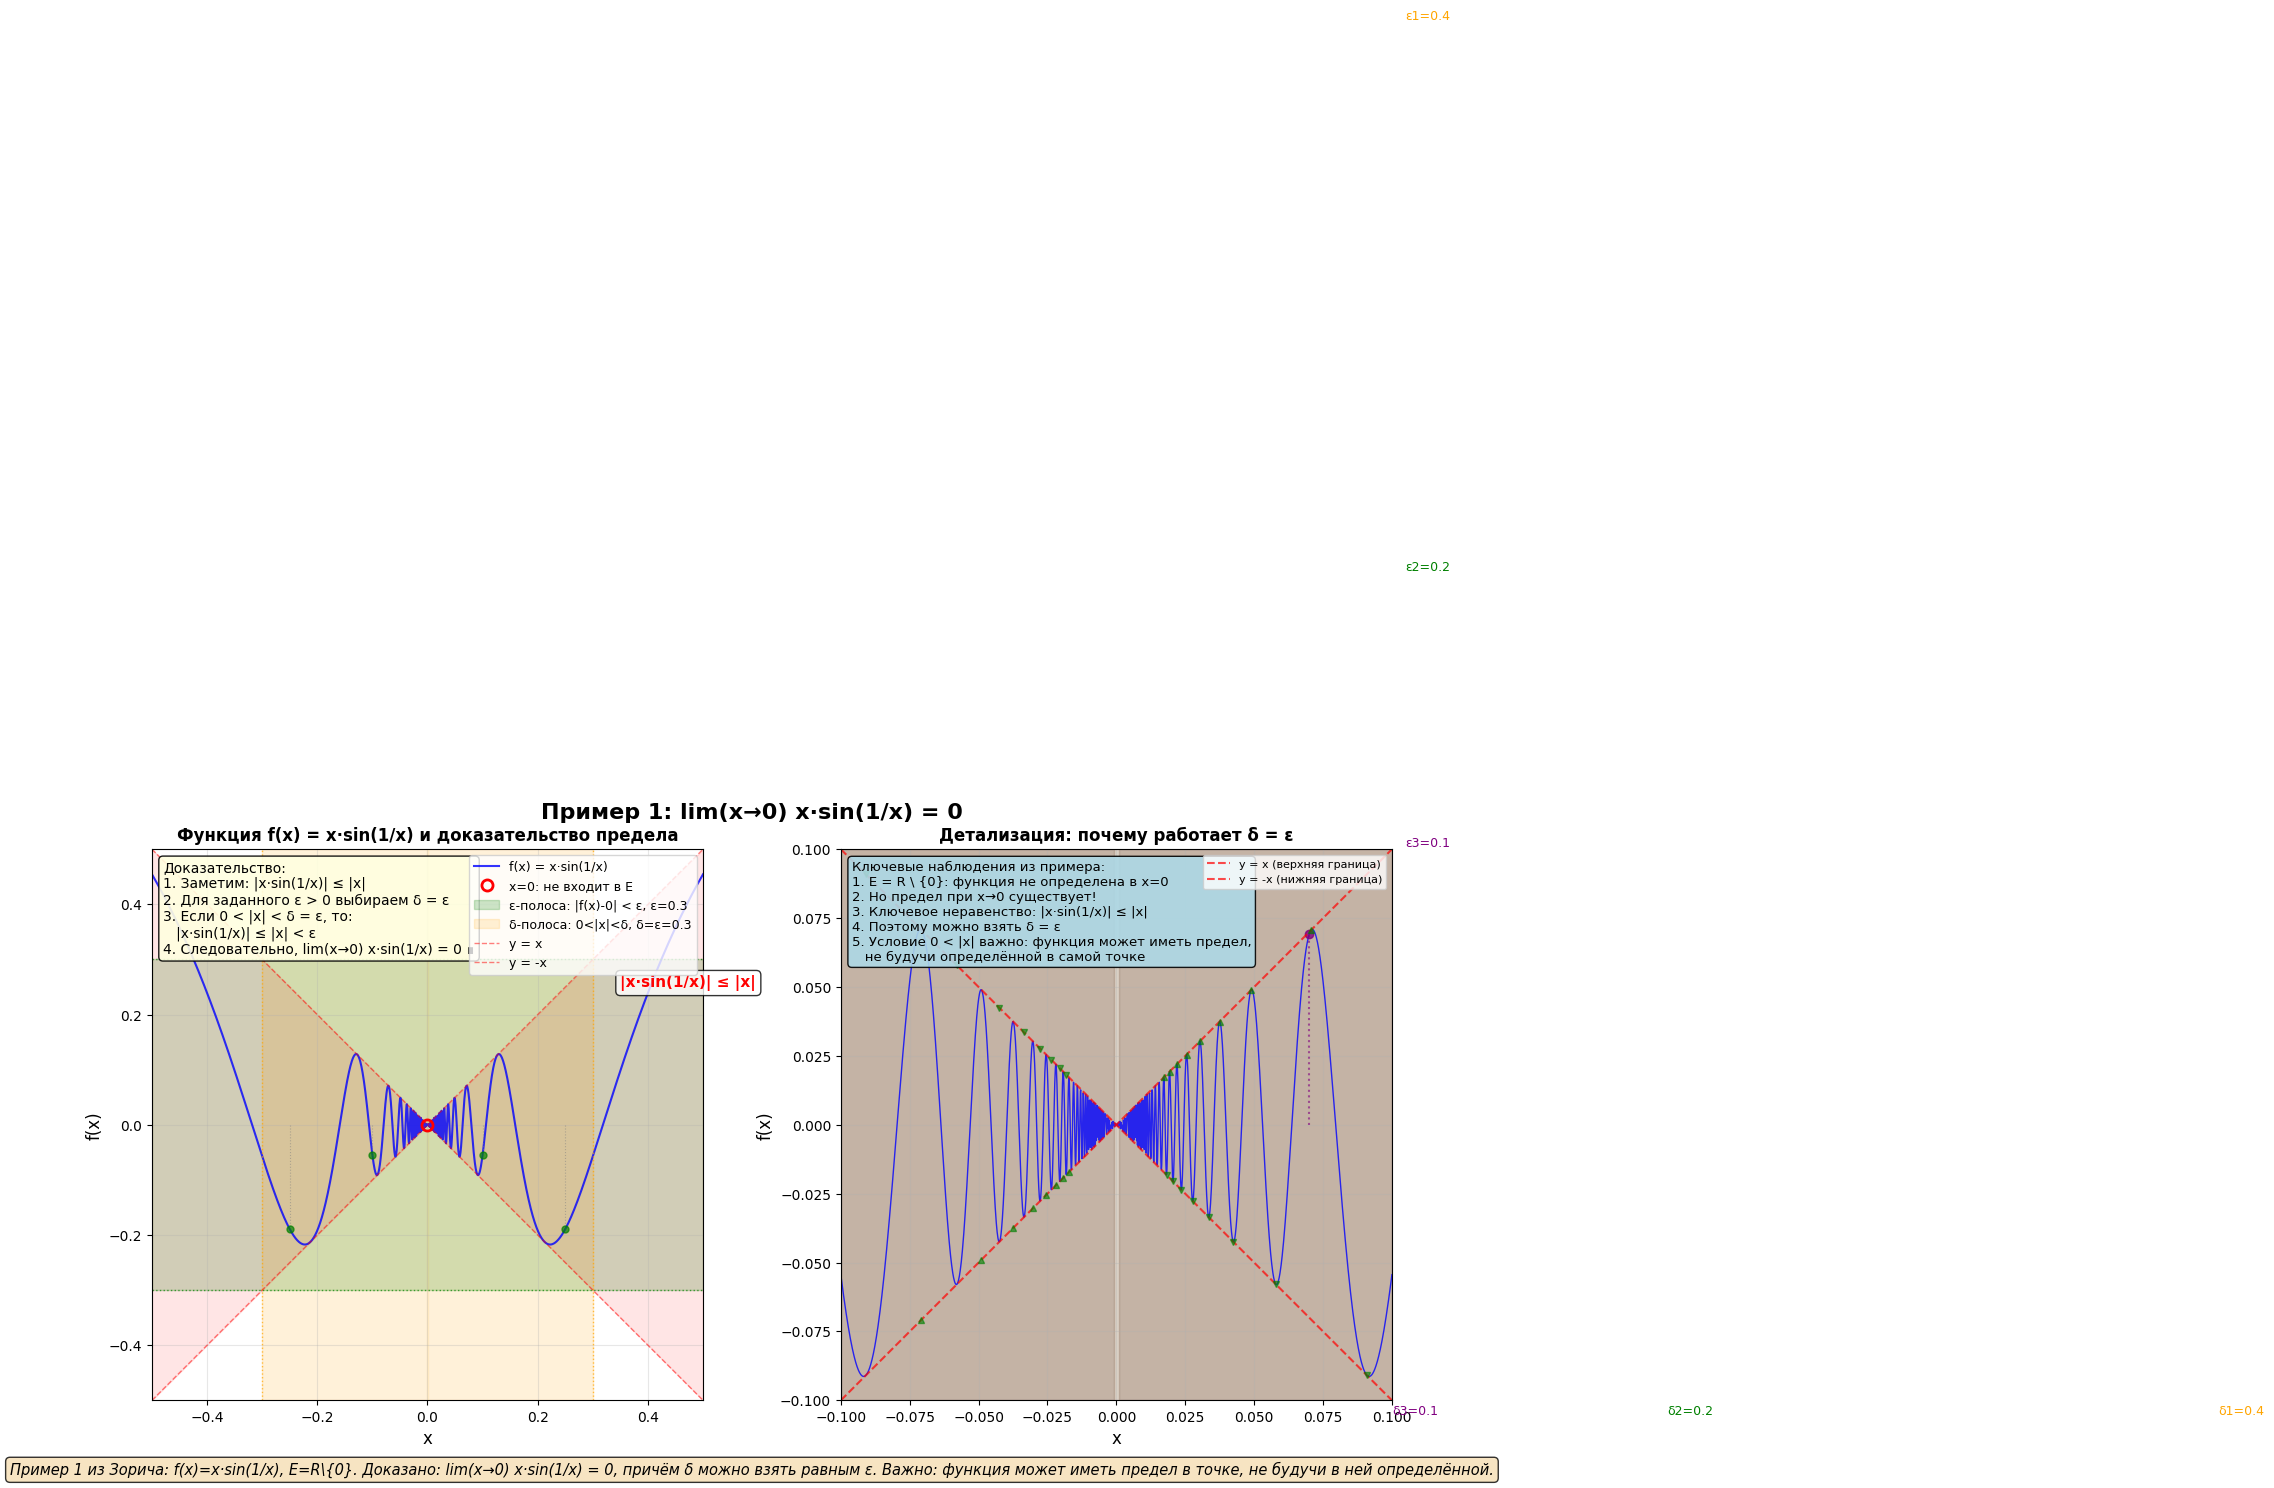

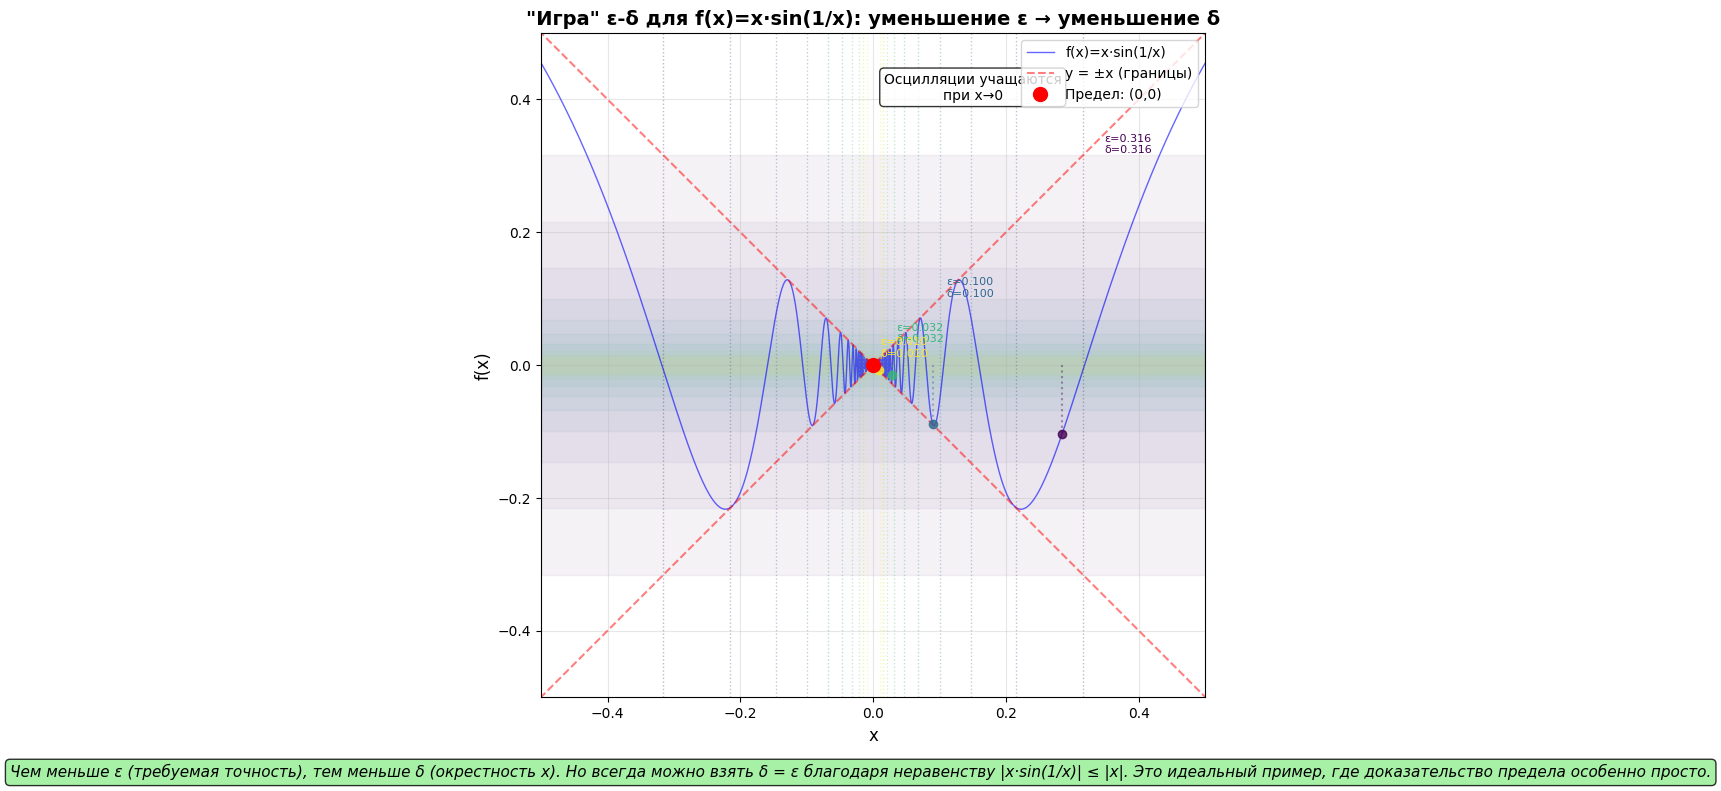

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Создаем фигуру
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Пример 1: lim(x→0) x·sin(1/x) = 0', 
             fontsize=16, fontweight='bold', y=0.98)

# Параметры из примера
a = 0  # Точка, к которой стремится x
A = 0  # Предел
epsilon = 0.3  # Как в примере
delta = epsilon  # Ключевое: δ = ε

# Функция из примера
def f(x):
    with np.errstate(divide='ignore', invalid='ignore'):
        return x * np.sin(1/x)

# Область определения E = R \ {0}
x_left = np.linspace(-0.5, -0.001, 1000)
x_right = np.linspace(0.001, 0.5, 1000)
x = np.concatenate([x_left, x_right])
y = f(x)

# График 1: Функция и ε-δ демонстрация
ax1.set_title('Функция f(x) = x·sin(1/x) и доказательство предела', 
              fontsize=12, fontweight='bold')

# Рисуем функцию
ax1.plot(x, y, 'b-', linewidth=1.5, alpha=0.8, label='f(x) = x·sin(1/x)')

# Показываем, что функция не определена в x=0
ax1.plot(0, 0, 'ro', markersize=8, markerfacecolor='none', 
         markeredgewidth=2, label='x=0: не входит в E')

# Рисуем ε-полосу
ax1.axhspan(-epsilon, epsilon, alpha=0.2, color='green',
           label=f'ε-полоса: |f(x)-0| < ε, ε={epsilon}')

# Рисуем δ-полосу (проколотую)
ax1.axvspan(-delta, -0.001, alpha=0.15, color='orange', 
           label=f'δ-полоса: 0<|x|<δ, δ=ε={delta}')
ax1.axvspan(0.001, delta, alpha=0.15, color='orange')

# Отмечаем границы
ax1.axhline(y=epsilon, color='green', linestyle=':', alpha=0.7, linewidth=1)
ax1.axhline(y=-epsilon, color='green', linestyle=':', alpha=0.7, linewidth=1)
ax1.axvline(x=delta, color='orange', linestyle=':', alpha=0.7, linewidth=1)
ax1.axvline(x=-delta, color='orange', linestyle=':', alpha=0.7, linewidth=1)

# Показываем ключевое неравенство: |x·sin(1/x)| ≤ |x|
# Рисуем линии y = x и y = -x
x_line = np.linspace(-0.5, 0.5, 100)
ax1.plot(x_line, x_line, 'r--', alpha=0.5, linewidth=1, label='y = x')
ax1.plot(x_line, -x_line, 'r--', alpha=0.5, linewidth=1, label='y = -x')

# Закрашиваем область между y=x и y=-x
ax1.fill_between(x_line, -x_line, x_line, color='red', alpha=0.1)

# Подписываем ключевое наблюдение
ax1.text(0.35, 0.25, '|x·sin(1/x)| ≤ |x|', fontsize=11, 
         fontweight='bold', color='red', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Показываем несколько точек и их связь с неравенством
test_points = [-0.25, -0.1, 0.1, 0.25]
for xp in test_points:
    yp = f(xp)
    ax1.plot([xp, xp], [0, yp], 'gray', linestyle=':', alpha=0.5, linewidth=0.8)
    ax1.plot(xp, yp, 'go', markersize=5, alpha=0.7)

ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x)', fontsize=12)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 0.5)
ax1.set_ylim(-0.5, 0.5)
ax1.set_aspect('equal', adjustable='box')

# Добавляем доказательство на график (без LaTeX)
proof_text = (
    'Доказательство:\n'
    '1. Заметим: |x·sin(1/x)| ≤ |x|\n'
    '2. Для заданного ε > 0 выбираем δ = ε\n'
    '3. Если 0 < |x| < δ = ε, то:\n'
    '   |x·sin(1/x)| ≤ |x| < ε\n'
    '4. Следовательно, lim(x→0) x·sin(1/x) = 0 ∎'
)

ax1.text(0.02, 0.98, proof_text, transform=ax1.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# График 2: Детализация и "игра" ε-δ
ax2.set_title('Детализация: почему работает δ = ε', 
              fontsize=12, fontweight='bold')

# Создаем более детальный график около 0
x_detail = np.linspace(-0.1, 0.1, 2000)
x_detail = x_detail[x_detail != 0]  # Исключаем 0
y_detail = f(x_detail)

# Рисуем функцию с большим количеством точек
ax2.plot(x_detail, y_detail, 'b-', linewidth=1, alpha=0.8)

# Показываем несколько разных ε и соответствующих δ
epsilons = [0.4, 0.2, 0.1]
colors = ['orange', 'green', 'purple']

for i, (eps, col) in enumerate(zip(epsilons, colors)):
    # ε-полоса
    ax2.axhspan(-eps, eps, alpha=0.1, color=col)
    # δ-полоса (δ = ε)
    ax2.axvspan(-eps, -0.001, alpha=0.08, color=col)
    ax2.axvspan(0.001, eps, alpha=0.08, color=col)
    
    # Подписи
    ax2.text(0.105, eps, f'ε{i+1}={eps}', 
            fontsize=9, color=col, va='bottom')
    ax2.text(eps, -0.105, f'δ{i+1}={eps}', 
            fontsize=9, color=col, ha='left')
    
    # Показываем, что график внутри δ-полосы попадает в ε-полосу
    x_test = eps * 0.7
    y_test = f(x_test)
    ax2.plot([x_test, x_test], [0, y_test], color=col, linestyle=':', alpha=0.6)
    ax2.plot(x_test, y_test, 'o', color=col, markersize=6, alpha=0.8)

# Границы y = ±x
x_line_detail = np.linspace(-0.1, 0.1, 100)
ax2.plot(x_line_detail, x_line_detail, 'r--', alpha=0.7, linewidth=1.5, 
        label='y = x (верхняя граница)')
ax2.plot(x_line_detail, -x_line_detail, 'r--', alpha=0.7, linewidth=1.5, 
        label='y = -x (нижняя граница)')

# Показываем осцилляции
# Находим несколько максимумов/минимумов
for n in range(1, 10):
    x_max = 1/(2*np.pi*n + np.pi/2)
    x_min = 1/(2*np.pi*n - np.pi/2)
    
    if abs(x_max) < 0.1:
        ax2.plot(x_max, x_max, 'g^', markersize=5, alpha=0.6)
        ax2.plot(-x_max, -x_max, 'g^', markersize=5, alpha=0.6)
    
    if abs(x_min) < 0.1:
        ax2.plot(x_min, -x_min, 'gv', markersize=5, alpha=0.6)
        ax2.plot(-x_min, x_min, 'gv', markersize=5, alpha=0.6)

ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('f(x)', fontsize=12)
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-0.1, 0.1)
ax2.set_ylim(-0.1, 0.1)
ax2.set_aspect('equal', adjustable='box')

# Инсайты из примера
insights_text = (
    'Ключевые наблюдения из примера:\n'
    '1. E = R \\ {0}: функция не определена в x=0\n'
    '2. Но предел при x→0 существует!\n'
    '3. Ключевое неравенство: |x·sin(1/x)| ≤ |x|\n'
    '4. Поэтому можно взять δ = ε\n'
    '5. Условие 0 < |x| важно: функция может иметь предел,\n'
    '   не будучи определённой в самой точке'
)

ax2.text(0.02, 0.98, insights_text, transform=ax2.transAxes,
        fontsize=9.5, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.9))

# Общее пояснение внизу
fig.text(0.5, 0.02, 
         'Пример 1 из Зорича: f(x)=x·sin(1/x), E=R\\{0}. '
         'Доказано: lim(x→0) x·sin(1/x) = 0, причём δ можно взять равным ε. '
         'Важно: функция может иметь предел в точке, не будучи в ней определённой.',
         ha='center', fontsize=10.5, style='italic',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.subplots_adjust(bottom=0.12, top=0.92, wspace=0.25)
plt.show()

# Дополнительная визуализация: анимация уменьшения ε
fig2, ax3 = plt.subplots(figsize=(10, 8))
ax3.set_title('"Игра" ε-δ для f(x)=x·sin(1/x): уменьшение ε → уменьшение δ', 
              fontsize=14, fontweight='bold')

# Рисуем функцию
x_wide = np.linspace(-1, 1, 4000)
x_wide = x_wide[x_wide != 0]
y_wide = f(x_wide)
ax3.plot(x_wide, y_wide, 'b-', linewidth=1, alpha=0.6, label='f(x)=x·sin(1/x)')

# Границы y = ±x
x_bound = np.linspace(-1, 1, 100)
ax3.plot(x_bound, x_bound, 'r--', alpha=0.5, linewidth=1.5, label='y = ±x (границы)')
ax3.plot(x_bound, -x_bound, 'r--', alpha=0.5, linewidth=1.5)

# Показываем процесс: ε уменьшается, δ = ε уменьшается
epsilons_anim = np.logspace(-0.5, -2, 10)  # от ~0.3 до 0.01
colors_anim = plt.cm.viridis(np.linspace(0, 1, len(epsilons_anim)))

for i, (eps, col) in enumerate(zip(epsilons_anim, colors_anim)):
    delta_anim = eps  # δ = ε
    
    # ε-полоса
    ax3.axhspan(-eps, eps, alpha=0.05, color=col)
    
    # δ-полоса (только границы)
    ax3.axvline(x=delta_anim, color=col, linestyle=':', alpha=0.3, linewidth=1)
    ax3.axvline(x=-delta_anim, color=col, linestyle=':', alpha=0.3, linewidth=1)
    
    # Подпись для первых нескольких
    if i % 3 == 0:
        ax3.text(delta_anim*1.1, eps, f'ε={eps:.3f}\nδ={delta_anim:.3f}', 
                fontsize=8, color=col, va='bottom')
        
        # Показываем точку на границе
        x_point = delta_anim * 0.9
        y_point = f(x_point)
        ax3.plot(x_point, y_point, 'o', color=col, markersize=6, alpha=0.8)
        ax3.plot([x_point, x_point], [0, y_point], color=col, linestyle=':', alpha=0.4)

# Точка предела
ax3.plot(0, 0, 'ro', markersize=10, label='Предел: (0,0)', zorder=10)

# Осцилляции становятся чаще при приближении к 0
ax3.text(0.15, 0.4, 'Осцилляции учащаются\nпри x→0', fontsize=10,
        ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax3.set_xlabel('x', fontsize=12)
ax3.set_ylabel('f(x)', fontsize=12)
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(-0.5, 0.5)
ax3.set_ylim(-0.5, 0.5)
ax3.set_aspect('equal', adjustable='box')

# Вывод
fig2.text(0.5, 0.02,
         'Чем меньше ε (требуемая точность), тем меньше δ (окрестность x). '
         'Но всегда можно взять δ = ε благодаря неравенству |x·sin(1/x)| ≤ |x|. '
         'Это идеальный пример, где доказательство предела особенно просто.',
         ha='center', fontsize=11, style='italic',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.subplots_adjust(bottom=0.12, top=0.95)
plt.show()

**Definition 2.** A punctered neighborhood of a point is defined a neighborhood of the point from which the point itself has been excluded. 

If we denote a neighborhood of point $a$ by $U(a)$, then a punctered neighborhood of this point will be denoted by a symbol $\r{U}(a)$

The sets: $$U_E (a) := E \cap U(a), $$ $$\r{U}_E (a) := E \cap \r{U}(a)$$

shall be referred to as, respectively, a neighborhood of point $a$ in the set E and punctered neighborhood of point $a$ in the set $E$.

If $a$ is a limit point of $E$, then $\r{U}_{E}(a)\ne \emptyset$, regardless of the choice of neighborhood $U(a)$ 

If, for a moment, we adopt the somewhat cumbersome symbols $\r{U}_{E}^{\delta} (a)$ и $V_{\R}^{\varepsilon} (A)$ to denote the punctered $\delta$-neighborhood of point $a$  in the set $E$ and the $\varepsilon$-neighborhood of point $A$ in $\R$, respectively, then the aforementioned "$\varepsilon - \delta$ definition" if the limit of a function can be rewritten in the form: $$(\lim_{E \ni x \to a} f(x) = A) := \forall V^{\varepsilon}_{\R} (A) \ \exists \r{U}_E^{\delta} (a) \ (f(\r{U}_E^{\delta} (a)) \subset V^{\varepsilon}_{\R} (A))$$

This entry states that $A$ is the limit of the function $f : E \to \R$ as $x$ tends to $a$ along the set $E$, if for any $\varepsilon$-neighborhood $V^{\varepsilon}_{\R} (A)$ of point $A$, there exists a punctered $\delta$-neighborhood $\r{U}^{\delta}_{E} (a)$ of point $a$ in the set $E$, whose image $f : E \to \R$ is completely contained within the neighborhood $V_{\R}^{\varepsilon} (A)$. 

Considerring that any neighborhood of a point on the number line also contains some symmetric neighborhood ($\delta$-neighborhood) of that same point, we now arrive at the following form of the definition of the limit, which we shall consider fundamental.

**Definition 3.** 
$$(\lim_{E \ni x \to a} f(x) = A) \ := \ \forall V_{\R} (A) \ \exists \r{U}_E (a) \ (f(\r{U}_E (a)) \subset V_{\R} (A))$$

We now define the limit of a function $f : E \to \R$ at a limit point $a$ of $E$. The number $A$ is called the limit of $f(x)$ as $x$ tends $a$ along the set $E$ (written $\lim_{E \ni x \to a} f(x) = A$), provided that for every neighborhood $V$ of $A$ in $\R$, there exists a punctered neighborhood $U$ of $a$ in $E$ such that the image $f(U)$ unde the mapping $f : E \to \R$ is contained in $V$.

We have presented several formulations of the definition of the limit of a function. For real-valued functions, where $a$, $A \in \R$, these formulations are, as shown previously, equivalent. However, for different purposes, one form may be more convenient than another. For example, for numerical estimates, the initial $\varepsilon-\delta$ form is useful, as it specifies the permissible magnitude of the deviation of $x$ from $a$ that guarantees the deviation of $f(x)$ from $A$ will not exceed a given magnitude. 

From the standpoint of extending the concept of a limit to more general functions not defined on the number line, the latter (neighborhood-based) formulation is most convenient, and it is one we have highlighted. Incidentally, it is evident from this that we can define the concept of the limit of a mapping $f : X \to Y$ if we are provided with the definition of a neighborhood of a point in $X$ and $Y$ that is to say, if $X$ and $Y$ are endowed with a topology.

##### Example 2. The Sign Function

$$\mathrm{sgn}\, x = \begin{cases} 1 & \text{if } x > 0,\ 0 & \text{if } x = 0,\ -1 & \text{if } x < 0 \end{cases} \}$$

(read as "signum x") is defined on the entire real line. We shall show that it does not have a limit as $x$ tends to $0$.

In formal notation: $$\forall A \in \R \ \exists V(A) \ \forall \r{U}(0) \ \exists x \in \r{U}(0) (f(x) \notin V(A))$$
